# Numerical Simulation Laboratory 
## Exercises 11: Keras - Neural Network regression 

### Overview 

In this notebook our task will be to perform machine learning regression on noisy data with a Neural Network (NN).

We will explore how the ability to fit depends on the structure of the NN. The goal is also to build intuition about why prediction is difficult.

### The Prediction Problem

Consider a probabilistic process that gives rise to labeled data $(x,y)$. The data is generated by drawing samples from the equation

$$
    y_i= f(x_i) + \eta_i,
$$

where $f(x_i)$ is some fixed, but (possibly unknown) function, and $\eta_i$ is a Gaussian, uncorrelate noise variable such that

$$
\langle \eta_i \rangle=0 \\
\langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
$$

We will refer to the $f(x_i)$ as the **true features** used to generate the data. 

To make predictions, we will consider a NN that depends on its parameters, weights and biases. The functions that the NN can model respresent the **model class** that we are using to try to model the data and make predictions.

To learn the parameters of the NN, we will train our models on a **training data set** and then test the effectiveness of the NN on a *different* dataset, the **validation data set**. The reason we must divide our data into a training and test dataset is that the point of machine learning is to make accurate predictions about new data we have not seen.

To measure our ability to predict, we will learn our parameters by fitting our training dataset and then making predictions on our test data set. One common measure of predictive  performance of our algorithm is to compare the predictions,$\{y_j^\mathrm{pred}\}$, to the true values $\{y_j\}$. A commonly employed measure for this is the sum of the mean square-error (MSE) on the test set:
$$
MSE= \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2
$$

We will try to get a qualitative picture by examining plots on validation and training data.

### Linear fit

We start by considering the very simple case:
$$
f(x)=2x+1
$$

Let's start defining the parameters of an ideal linear function which we are going to predict through a neural network regression

___
### Exercise 11.1

In order to make practice with NN, explore how does the previous linear regression depend on the number of epochs, $N_{\mathrm{epochs}}$, the number of data points $N_{\mathrm{train}}$ and on the noise $\sigma$. Try to improve the previous result operating on these parameters.
___


In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(0)
tf.random.set_seed(0)

### Analisi cambiamento parametri

L'obiettivo di questo esercizio è utilizzare una rete neurale per effettuare una regressione lineare su dati sintetici generati dalla funzione: [ $f(x) = 2x + 1 $] con l'aggiunta di rumore gaussiano ( $\eta \sim \mathcal{N}(0, \sigma) $).

#### Passaggi principali
1. **Generazione dei dati sintetici:**

I dati vengono generati con la funzione generate_data, che crea ( $x$ ) uniformemente distribuiti in ($[-1, 1]$) e calcola ( $y$ ) aggiungendo rumore gaussiano con deviazione standard ( $\sigma$ ).
Parametri principali:
( $m = 2$ ): pendenza della retta.
( $b = 1$ ): intercetta.
( $\sigma$ ): livello di rumore.

2. **Definizione della rete neurale:**

La rete è composta da un singolo strato denso con un neurone e funzione di attivazione lineare.
- Ottimizzatore: sgd (discesa del gradiente stocastica).
- Funzione di perdita: mse (errore quadratico medio).

3. **Allenamento e valutazione:**

La rete viene allenata sui dati di training per un numero di epoche specificato.
I dati vengono divisi in training e test set (80%-20%). Le metriche calcolate sono:
- MSE: misura la differenza media quadratica tra i valori previsti e quelli reali.
- MAE: misura l'errore medio assoluto, utile per interpretare l'errore in unità della variabile target.
- RMSE: simile a MSE, ma penalizza maggiormente gli errori grandi.
- $R^2$: coefficiente di determinazione indice statistico che misura la bontà di adattamento di un modello di regressione, indicando quanta parte della variabilità della variabile dipendente viene spiegata dalle variabili indipendenti (misura quanto bene il modello spiega la varianza dei dati).

4. **Analisi dei parametri:**

Si esplora come il numero di epoche ($ N_{\text{epochs}} $), il numero di punti ($ N_{\text{train}} $) e il livello di rumore ($\sigma $) influenzano la capacità della rete di apprendere la relazione lineare.
Per la valutazione si considerano le metriche descritte sopra.

In [19]:
# parametri e funzioni

# parametri modello lineare
m=2
b=1

# funzione per generare dati sintetici
def generate_data(n_points=600, sigma=0.2, m=2, b=1, seed=0):
    np.random.seed(seed)
    x_data = np.random.uniform(-1, 1, n_points)
    y_data = m * x_data + b + np.random.normal(0, sigma, n_points)
    return x_data, y_data

# funzione per creare sempre la stessa rete
def build_model():
    model = Sequential([
        Dense(1, input_shape=(1,))
    ])
    model.compile(optimizer='sgd', loss='mse', metrics=['mse'])
    return model

# funzione per allenare e valutare una singola configurazione
def run_experiment(epochs=30, n_points=600, sigma=0.2, test_size=0.2, random_state=42):
    # dati
    x_data, y_data = generate_data(n_points=n_points, sigma=sigma, m=m, b=b, seed=0)

    x_train, x_test, y_train, y_test = train_test_split(
        x_data, y_data, test_size=test_size, random_state=random_state, shuffle=True
    )

    # reshape per keras
    x_train_nn = x_train.reshape(-1, 1)
    x_test_nn = x_test.reshape(-1, 1)

    # modello
    tf.random.set_seed(0)
    model = build_model()

    # training
    history = model.fit(
        x_train_nn, y_train,
        epochs=epochs,
        batch_size=32,
        shuffle=True,
        validation_data=(x_test_nn, y_test),
        verbose=0
    )

    # predizioni
    y_pred = model.predict(x_test_nn, verbose=0).flatten()

    # metriche
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # pesi appresi
    weights, bias = model.get_weights()
    learned_m = weights[0][0]
    learned_b = bias[0]

    return {
        'model': model,
        'history': history,
        'x_train': x_train,
        'x_test': x_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'learned_m': learned_m,
        'learned_b': learned_b,
        'epochs': epochs,
        'n_points': n_points,
        'sigma': sigma
    }
    
# funzione per plottare loss e predizioni
def plot_results(result):
    history = result['history']
    x_test = result['x_test']
    y_test = result['y_test']
    y_pred = result['y_pred']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(
        f"Loss vs Epochs\n(epochs={result['epochs']}, n_points={result['n_points']}, sigma={result['sigma']})"
    )
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()
    axes[0].grid(True)

    # Predizioni vs test
    sort_idx = np.argsort(x_test)
    x_sorted = x_test[sort_idx]
    y_test_sorted = y_test[sort_idx]
    y_pred_sorted = y_pred[sort_idx]

    axes[1].scatter(x_test, y_test, alpha=0.6, label='Test points')
    axes[1].plot(x_sorted, y_pred_sorted, color='red', linewidth=2, label='Model prediction')
    axes[1].plot(
        np.linspace(-1, 1, 100),
        m * np.linspace(-1, 1, 100) + b,
        color='green',
        linestyle='--',
        label='True law'
    )
    axes[1].set_title(
        f"Predictions on Test Set\nm={result['learned_m']:.3f}, b={result['learned_b']:.3f}"
    )
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    
# funzione per stampare le metriche    
def print_metrics(result):
    print(f"Configuration: epochs={result['epochs']}, n_points={result['n_points']}, sigma={result['sigma']}")
    print(f"Learned slope m     = {result['learned_m']:.4f}")
    print(f"Learned intercept b = {result['learned_b']:.4f}")
    print(f"MSE  = {result['mse']:.6f}")
    print(f"MAE  = {result['mae']:.6f}")
    print(f"RMSE = {result['rmse']:.6f}")
    print(f"R^2  = {result['r2']:.6f}")
    
# funzione per grafici da csv
def plot_results_from_csv(epochs, n_points, sigma,
                          summary_file="linear_experiment_results.csv",
                          loss_file="linear_experiment_loss_data.csv",
                          pred_file="linear_experiment_pred_data.csv"):
    
    summary_df = pd.read_csv(summary_file)
    loss_df = pd.read_csv(loss_file)
    pred_df = pd.read_csv(pred_file)

    summary_row = summary_df[
        (summary_df['epochs'] == epochs) &
        (summary_df['n_points'] == n_points) &
        (summary_df['sigma'] == sigma)
    ]

    loss_subset = loss_df[
        (loss_df['epochs'] == epochs) &
        (loss_df['n_points'] == n_points) &
        (loss_df['sigma'] == sigma)
    ]

    pred_subset = pred_df[
        (pred_df['epochs'] == epochs) &
        (pred_df['n_points'] == n_points) &
        (pred_df['sigma'] == sigma)
    ]

    if summary_row.empty or loss_subset.empty or pred_subset.empty:
        print(f"Nessun dato trovato per epochs={epochs}, n_points={n_points}, sigma={sigma}")
        return

    summary_row = summary_row.iloc[0]
    learned_m = summary_row['learned_m']
    learned_b = summary_row['learned_b']

    pred_subset = pred_subset.sort_values(by='x_test')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # grafico loss
    axes[0].plot(loss_subset['epoch'], loss_subset['train_loss'], label='Train Loss')
    axes[0].plot(loss_subset['epoch'], loss_subset['val_loss'], label='Validation Loss')
    axes[0].set_title(f"Loss vs Epoche\n(epochs={epochs}, n_points={n_points}, sigma={sigma})")
    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("MSE Loss")
    axes[0].legend()
    axes[0].grid(True)

    # grafico predizione
    axes[1].scatter(pred_subset['x_test'], pred_subset['y_test'], alpha=0.6, label='Test points')
    axes[1].plot(pred_subset['x_test'], pred_subset['y_pred'], color='red', linewidth=2, label='Model prediction')

    x_theoretical = np.linspace(-1, 1, 100)
    y_theoretical = m * x_theoretical + b
    axes[1].plot(x_theoretical, y_theoretical, color='green', linestyle='--', label='True law')

    axes[1].set_title(f"Predizioni sul test set\nm={learned_m:.3f}, b={learned_b:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("y")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()
    
# funzione per stampare metriche di una singola configurazione da csv
def print_metrics_from_csv(epochs, n_points, sigma,
                           summary_file="linear_experiment_results.csv"):
    summary_df = pd.read_csv(summary_file)

    row = summary_df[
        (summary_df['epochs'] == epochs) &
        (summary_df['n_points'] == n_points) &
        (summary_df['sigma'] == sigma)
    ]

    if row.empty:
        print(f"Nessun risultato trovato per epochs={epochs}, n_points={n_points}, sigma={sigma}")
        return

    row = row.iloc[0]

    print(f"Configuration: epochs={int(row['epochs'])}, n_points={int(row['n_points'])}, sigma={row['sigma']}")
    print(f"Learned slope m     = {row['learned_m']:.4f}")
    print(f"Learned intercept b = {row['learned_b']:.4f}")
    print(f"MSE  = {row['mse']:.6f}")
    print(f"MAE  = {row['mae']:.6f}")
    print(f"RMSE = {row['rmse']:.6f}")
    print(f"R^2  = {row['r2']:.6f}")

/opt/anaconda3/envs/dl2026/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Configuration: epochs=30, n_points=600, sigma=0.2
Learned slope m     = 1.8241
Learned intercept b = 0.9946
MSE  = 0.039243
MAE  = 0.161942
RMSE = 0.198098
R^2  = 0.971770


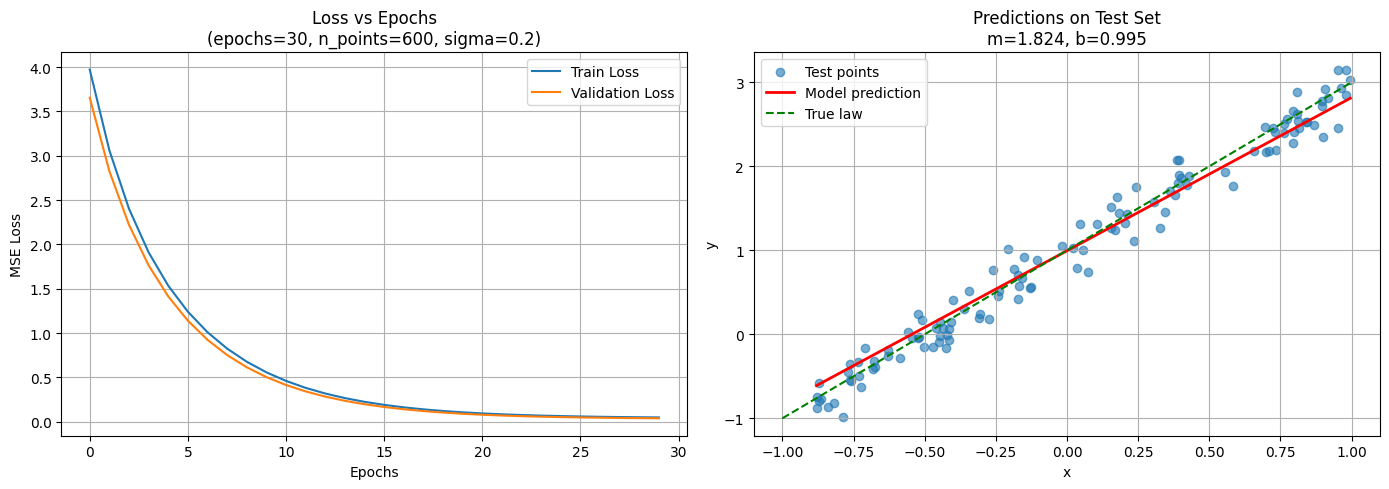

In [14]:
# test singola configurazione
result = run_experiment(epochs=30, n_points=600, sigma=0.2)
print_metrics(result)
plot_results(result)

In [24]:
# Test su diverse configurazioni
epochs_list = [10, 30, 50, 100]
n_points_list = [100, 300, 600, 1000]
sigma_list = [0.05, 0.2, 0.5, 1.0]

# esperimenti
all_results = []

for epochs in epochs_list:
    for n_points in n_points_list:
        for sigma in sigma_list:
            result = run_experiment(epochs=epochs, n_points=n_points, sigma=sigma)
            all_results.append(result)
            print_metrics(result)
            print("-" * 50)
            
# tabella riassuntiva dei risultati
summary = pd.DataFrame([
    {
        'epochs': r['epochs'],
        'n_points': r['n_points'],
        'sigma': r['sigma'],
        'learned_m': r['learned_m'],
        'learned_b': r['learned_b'],
        'mse': r['mse'],
        'mae': r['mae'],
        'rmse': r['rmse'],
        'r2': r['r2']
    }
    for r in all_results
])

summary.sort_values(by=['sigma', 'n_points', 'epochs'])
summary.to_csv("linear_experiment_results.csv", index=False) # salvataggio metriche

# dati per loss curves
loss_rows = []

for exp_id, r in enumerate(all_results):
    train_loss = r['history'].history['loss']
    val_loss = r['history'].history['val_loss']
    
    for epoch_idx, (loss, val_loss_i) in enumerate(zip(train_loss, val_loss), start=1):
        loss_rows.append({
            'exp_id': exp_id,
            'epochs': r['epochs'],
            'n_points': r['n_points'],
            'sigma': r['sigma'],
            'epoch': epoch_idx,
            'train_loss': loss,
            'val_loss': val_loss_i
        })

loss_df = pd.DataFrame(loss_rows)
loss_df.to_csv("linear_experiment_loss_data.csv", index=False)

# dati per grafico predizioni vs test
pred_rows = []

for exp_id, r in enumerate(all_results):
    for x, y_true, y_hat in zip(r['x_test'], r['y_test'], r['y_pred']):
        pred_rows.append({
        'exp_id': exp_id,
        'epochs': r['epochs'],
        'n_points': r['n_points'],
        'sigma': r['sigma'],
        'x_test': x,
        'y_test': y_true,
        'y_pred': y_hat
        })

pred_df = pd.DataFrame(pred_rows)
pred_df.to_csv("linear_experiment_pred_data.csv", index=False)

/opt/anaconda3/envs/dl2026/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Configuration: epochs=10, n_points=100, sigma=0.05
Learned slope m     = 1.5714
Learned intercept b = 0.4420
MSE  = 0.391829
MAE  = 0.592950
RMSE = 0.625962
R^2  = 0.541464
--------------------------------------------------


/opt/anaconda3/envs/dl2026/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Configuration: epochs=10, n_points=100, sigma=0.2
Learned slope m     = 0.0246
Learned intercept b = 0.3910
MSE  = 1.431676
MAE  = 0.994441
RMSE = 1.196527
R^2  = -0.650129
--------------------------------------------------


/opt/anaconda3/envs/dl2026/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

Configuration: epochs=100, n_points=1000, sigma=0.2
Learned slope m     = 1.9833
Learned intercept b = 1.0030
MSE  = 0.031112
MAE  = 0.136408
RMSE = 0.176386
R^2  = 0.976390
--------------------------------------------------


/opt/anaconda3/envs/dl2026/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Configuration: epochs=100, n_points=1000, sigma=0.5
Learned slope m     = 1.9584
Learned intercept b = 1.0074
MSE  = 0.194451
MAE  = 0.341019
RMSE = 0.440966
R^2  = 0.872391
--------------------------------------------------


/opt/anaconda3/envs/dl2026/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Configuration: epochs=100, n_points=1000, sigma=1.0
Learned slope m     = 1.9167
Learned intercept b = 1.0148
MSE  = 0.777803
MAE  = 0.682038
RMSE = 0.881932
R^2  = 0.642211
--------------------------------------------------


In [25]:
load_results = pd.read_csv("linear_experiment_results.csv")

Configurazione: epochs=10, n_points=600, sigma=0.2
Learned slope m     = 0.8529
Learned intercept b = 0.9337
MSE  = 0.471547
MAE  = 0.600411
RMSE = 0.686693
R^2  = 0.660778


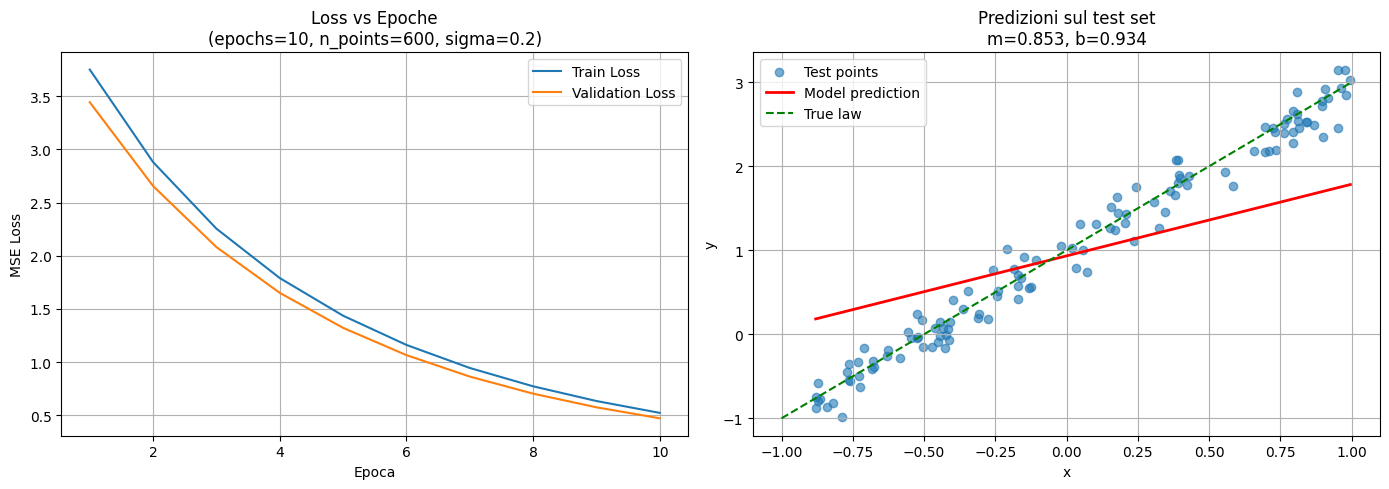

Configurazione: epochs=30, n_points=600, sigma=0.2
Learned slope m     = 1.8537
Learned intercept b = 0.9950
MSE  = 0.036685
MAE  = 0.156220
RMSE = 0.191532
R^2  = 0.973610


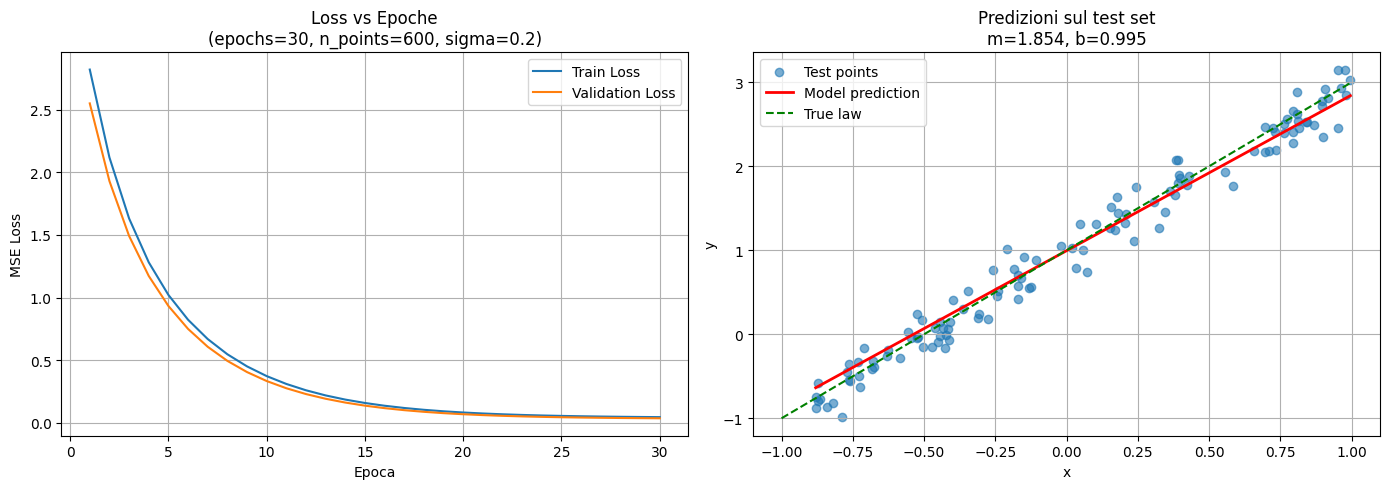

Configurazione: epochs=50, n_points=600, sigma=0.2
Learned slope m     = 1.9601
Learned intercept b = 0.9968
MSE  = 0.032626
MAE  = 0.143400
RMSE = 0.180628
R^2  = 0.976529


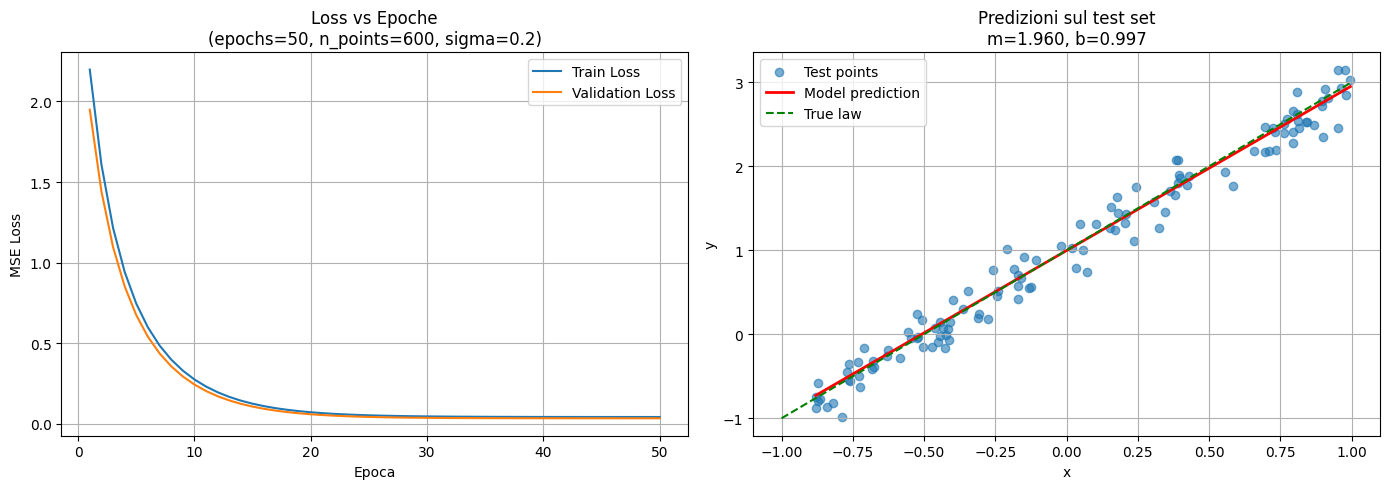

Configurazione: epochs=100, n_points=600, sigma=0.2
Learned slope m     = 1.9728
Learned intercept b = 0.9970
MSE  = 0.032678
MAE  = 0.142698
RMSE = 0.180769
R^2  = 0.976492


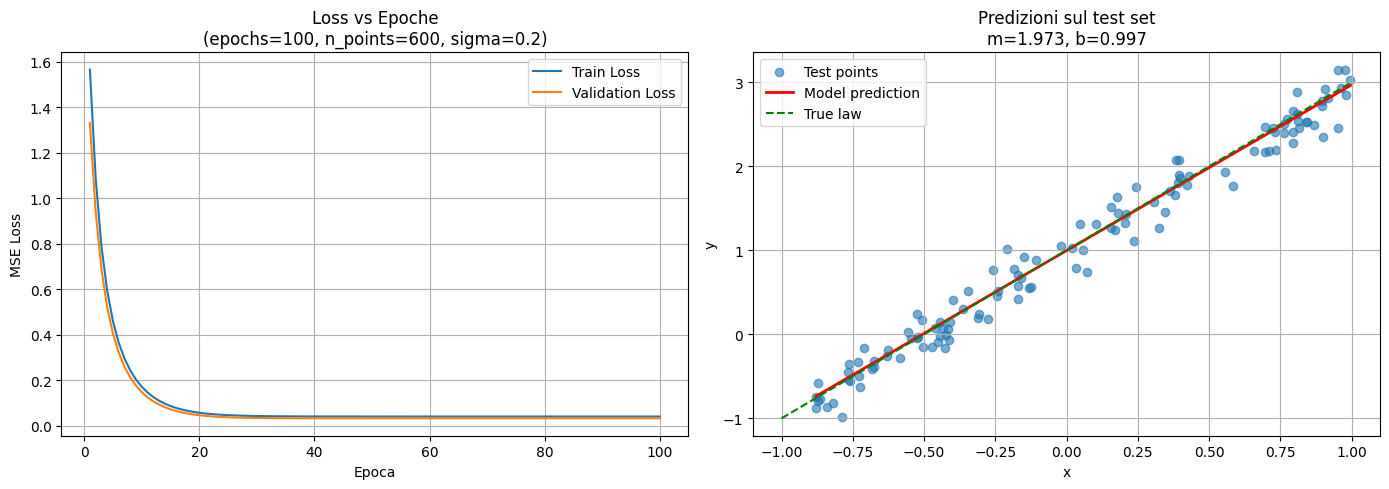

In [27]:
# confronto diverse epochs
n_points = 600
sigma = 0.2
epochs_list = [10, 30, 50, 100]

configs_epochs = [
    (epochs, n_points, sigma) for epochs in epochs_list
]

for epochs, n_points, sigma in configs_epochs:
    print_metrics_from_csv(epochs, n_points, sigma)
    plot_results_from_csv(epochs, n_points, sigma)

Aumentando il numero di epochs diminuisce la loss diminuisce, fino a un punto in cui l'ulteriore aumento di epoche non produce miglioramenti visibili.

Configurazione: epochs=50, n_points=100, sigma=0.2
Learned slope m     = 1.7315
Learned intercept b = 0.9655
MSE  = 0.055675
MAE  = 0.207690
RMSE = 0.235955
R^2  = 0.935830


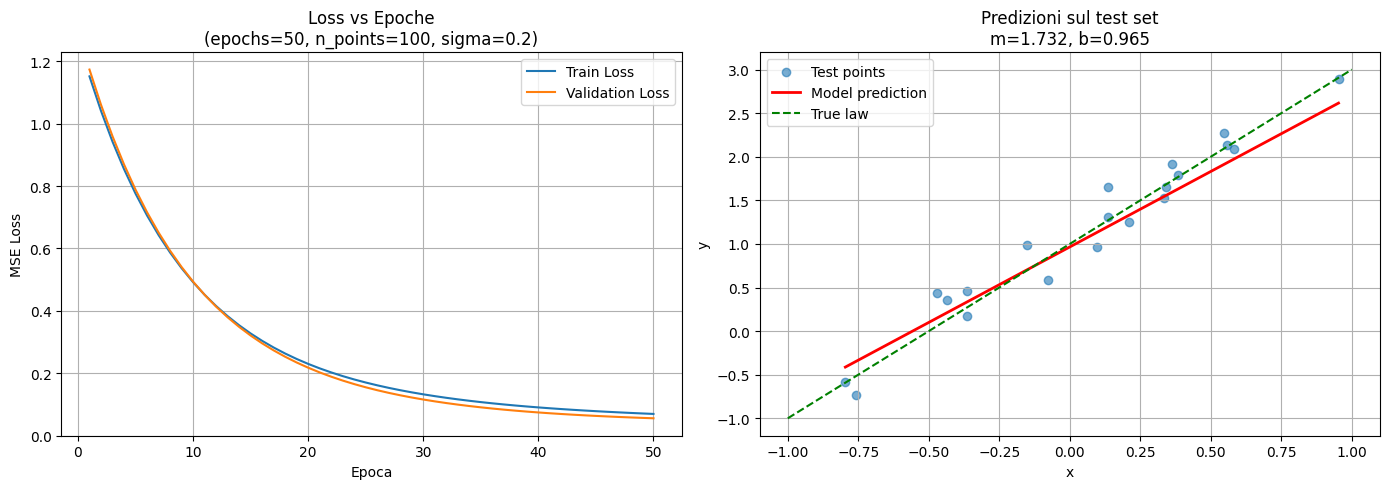

Configurazione: epochs=50, n_points=300, sigma=0.2
Learned slope m     = 1.7823
Learned intercept b = 0.9814
MSE  = 0.052496
MAE  = 0.182078
RMSE = 0.229120
R^2  = 0.958584


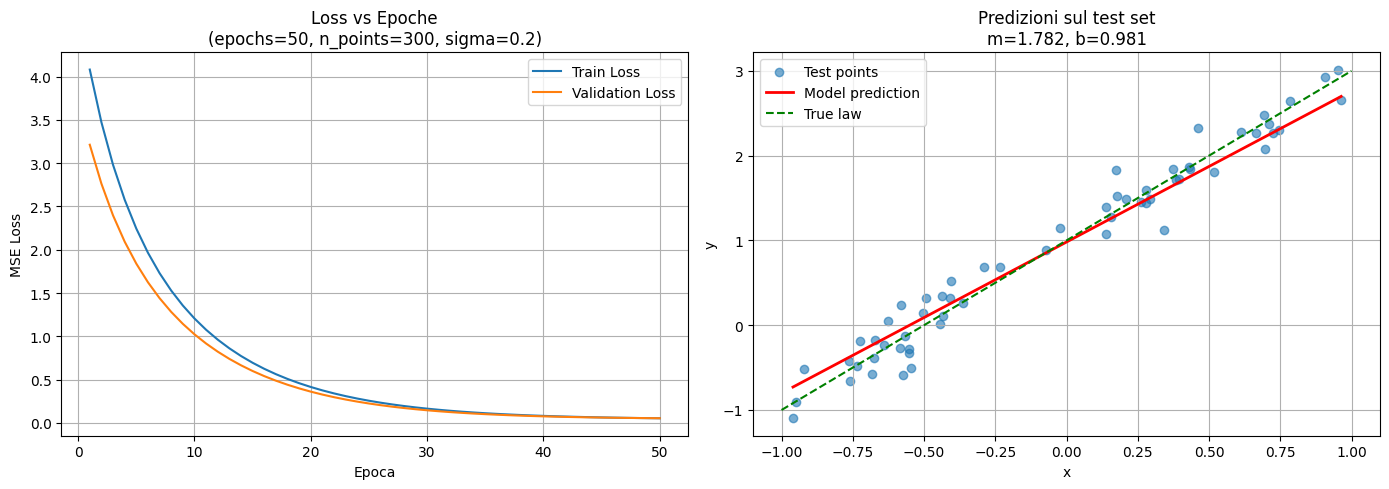

Configurazione: epochs=50, n_points=600, sigma=0.2
Learned slope m     = 1.9601
Learned intercept b = 0.9968
MSE  = 0.032626
MAE  = 0.143400
RMSE = 0.180628
R^2  = 0.976529


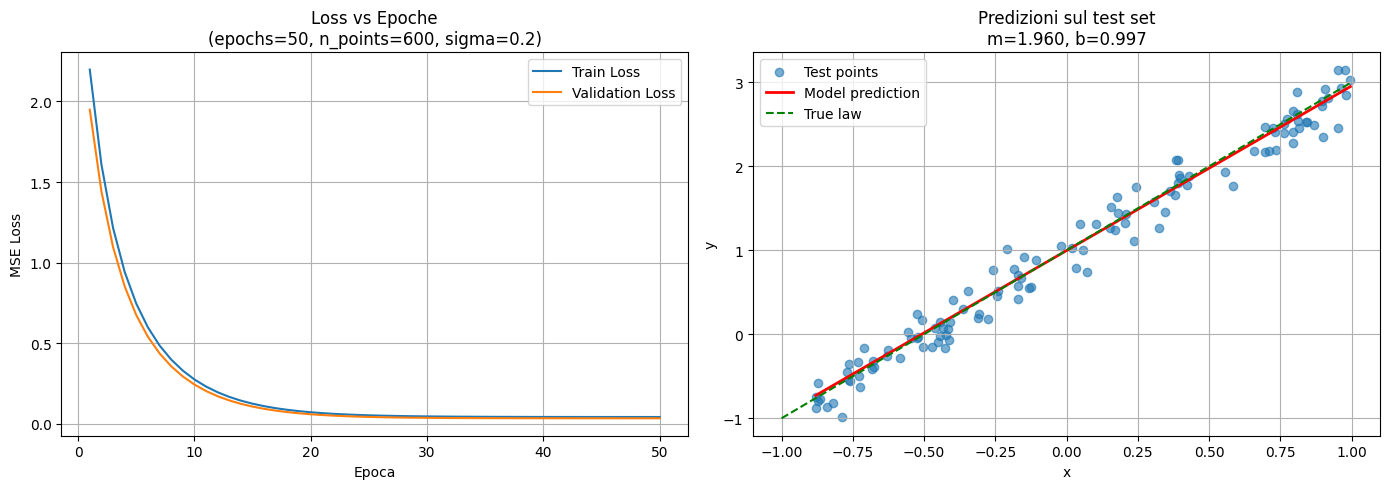

Configurazione: epochs=50, n_points=1000, sigma=0.2
Learned slope m     = 1.9828
Learned intercept b = 1.0030
MSE  = 0.031126
MAE  = 0.136414
RMSE = 0.176425
R^2  = 0.976379


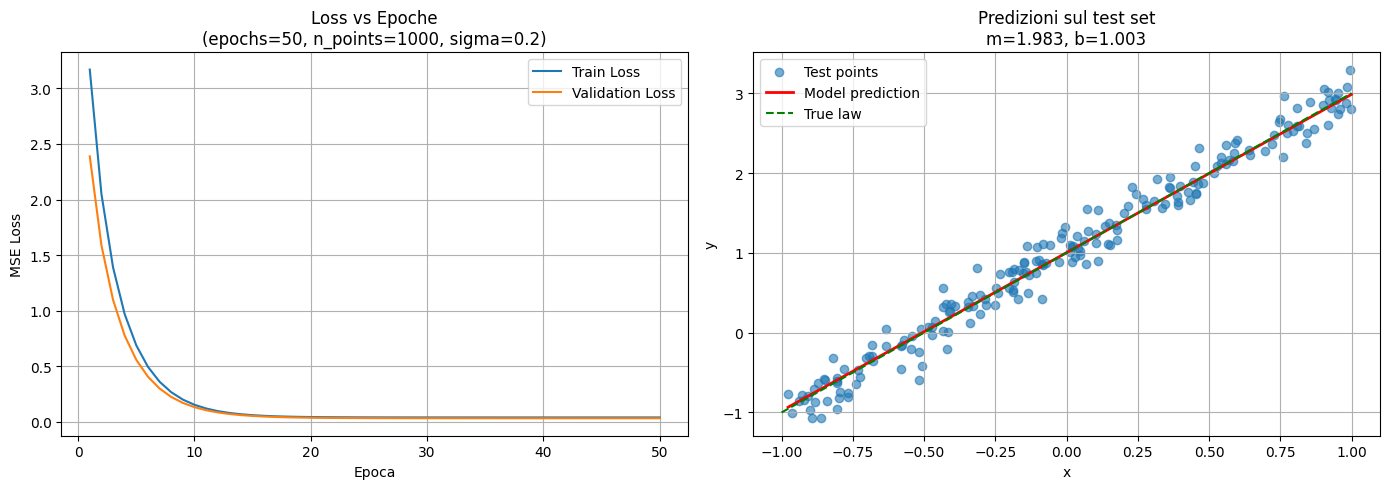

In [28]:
# confronto diverse n_points
n_points_list = [100, 300, 600, 1000]
sigma = 0.2
epochs = 50

configs_n_points = [
    (epochs, n_points, sigma) for n_points in n_points_list
]

for epochs, n_points, sigma in configs_n_points:
    print_metrics_from_csv(epochs, n_points, sigma)
    plot_results_from_csv(epochs, n_points, sigma)

All'aumentare del numero di punti si osserva una validation loss più stabile. Un maggiorn numero di punti consente in generale alla rete di fare una stima più robusta della funzione sottostante.

Configurazione: epochs=50, n_points=600, sigma=0.05
Learned slope m     = 1.9835
Learned intercept b = 0.9991
MSE  = 0.002055
MAE  = 0.036283
RMSE = 0.045335
R^2  = 0.998528


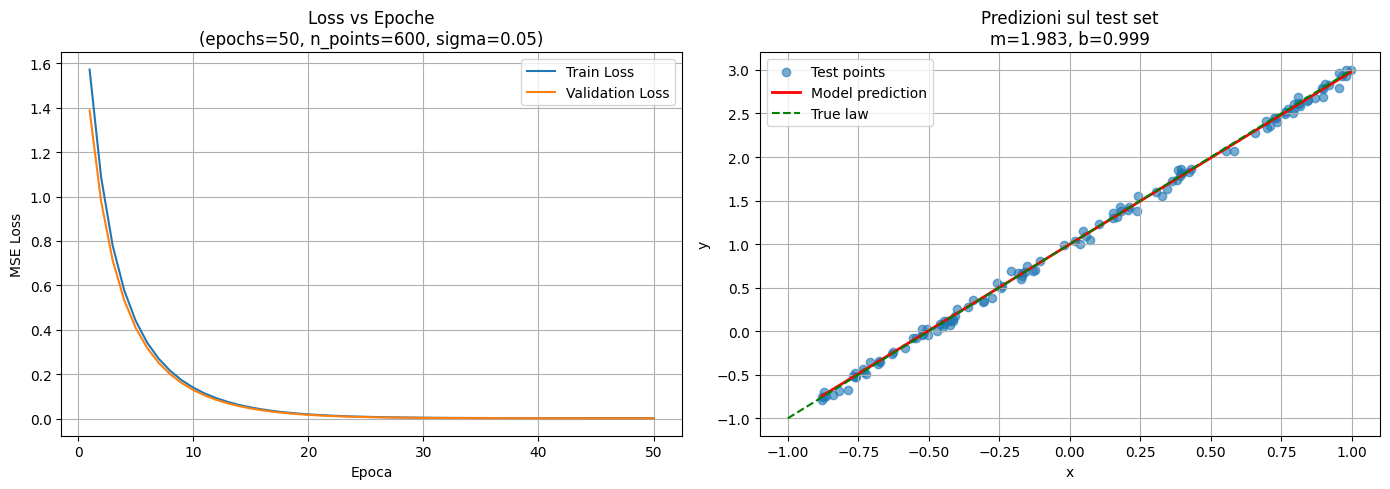

Configurazione: epochs=50, n_points=600, sigma=0.2
Learned slope m     = 1.9601
Learned intercept b = 0.9968
MSE  = 0.032626
MAE  = 0.143400
RMSE = 0.180628
R^2  = 0.976529


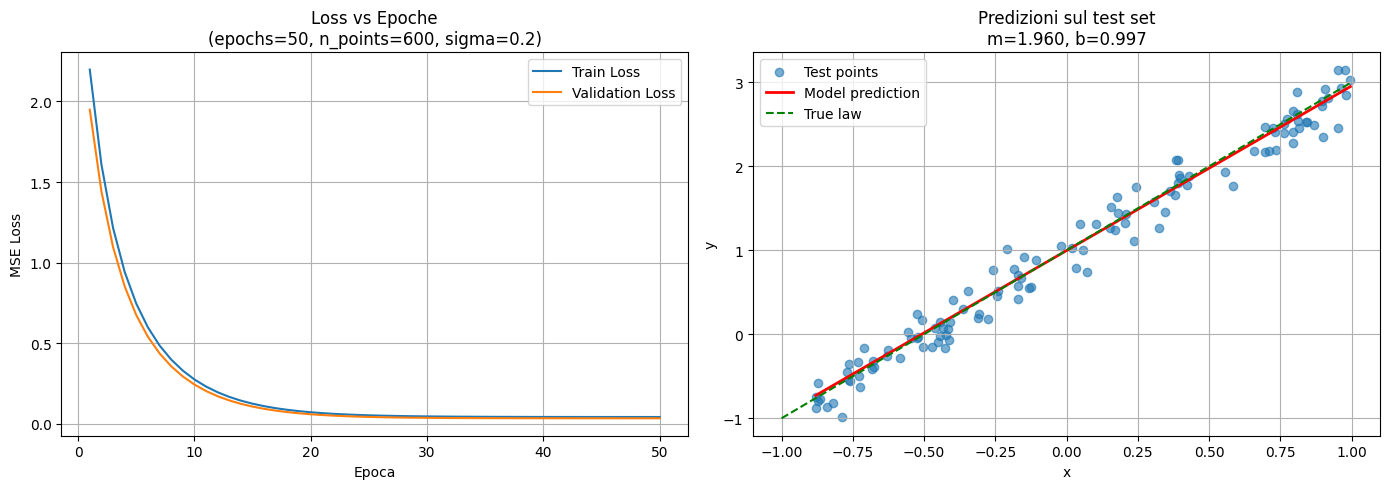

Configurazione: epochs=50, n_points=600, sigma=0.5
Learned slope m     = 1.9265
Learned intercept b = 0.9924
MSE  = 0.204126
MAE  = 0.356986
RMSE = 0.451803
R^2  = 0.862539


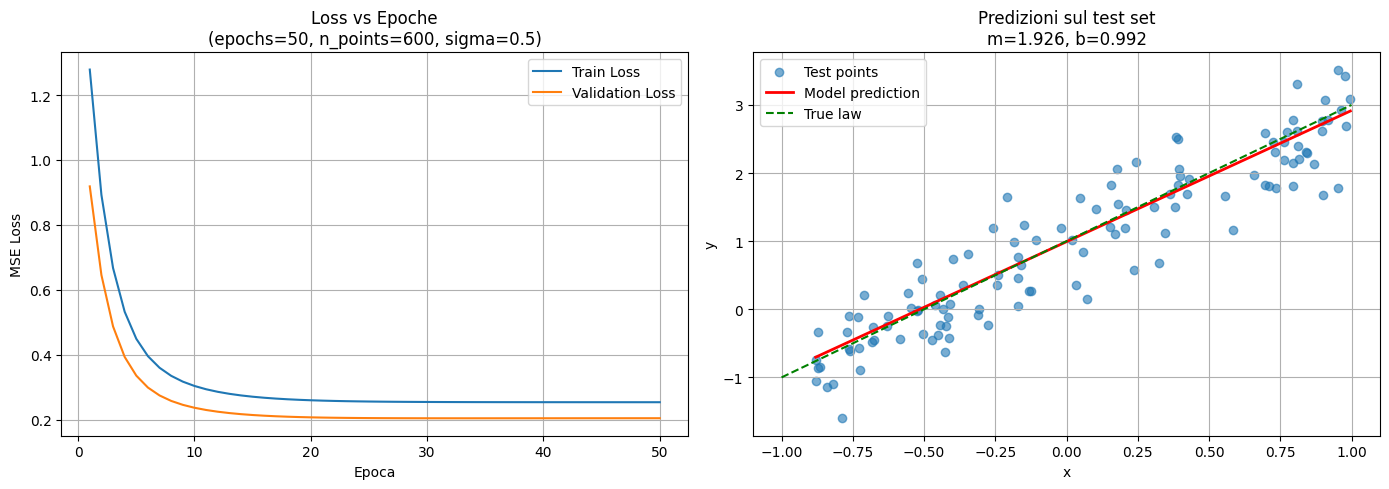

Configurazione: epochs=50, n_points=600, sigma=1.0
Learned slope m     = 1.8616
Learned intercept b = 0.9850
MSE  = 0.816831
MAE  = 0.713602
RMSE = 0.903787
R^2  = 0.583967


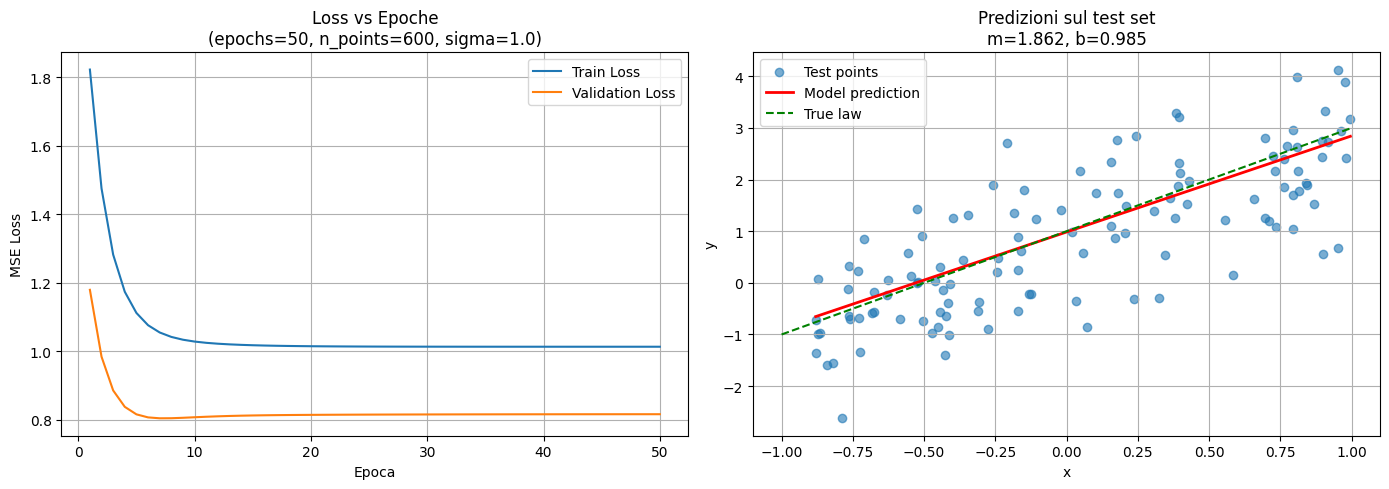

In [29]:
# confronto diverse sigma
n_points = 600
sigma_list = [0.05, 0.2, 0.5, 1.0]
epochs = 50

configs_sigma = [
    (epochs, n_points, sigma) for sigma in sigma_list
]

for epochs, n_points, sigma in configs_sigma:
    print_metrics_from_csv(epochs, n_points, sigma)
    plot_results_from_csv(epochs, n_points, sigma)

All'aumentare del rumore, le losses chiaramente peggiorano, non significa però che mediamente, il modello non riesca a imparare la tendenza media dei dati (seppur molto rumorosi). 

___
### Exercise 11.2

Try to extend the model to obtain a reasonable fit of the following polynomial of order 3:

$$
f(x)=4-3x-2x^2+3x^3
$$
for $x \in [-1,1]$.

Find good (& reasonable) choices for:

- the number of layers
- the number of neurons in each layer
- the activation function
- the optimizer
- the loss function
  
Check your NN model by seeing how well your fits predict newly generated test data (including on data outside the range you fit). How well do your NN do on points in the range of $x$ where you trained the model? How about points outside the original training data set? 
Summarize what you have learned about the relationship between model complexity (number of parameters), goodness of fit on training data, and the ability to predict well.
___

### Passaggi principali:
1. **Definizione della rete neurale:**

- La rete è composta da uno o più strati nascosti con un numero variabile di neuroni.
- Funzioni di attivazione: tanh o relu.
- Ottimizzatori: adam o sgd.
- Funzione di perdita: mse.

2. **Grid search:**

- Si esplorano diverse configurazioni della rete:
 - Numero di strati nascosti e neuroni per strato.
 - Funzioni di attivazione.
 - Ottimizzatori.
- Numero di epoche e dimensione del batch.
 - Per ogni configurazione, si calcolano le metriche di performance.

3. **Metriche considerate:**
- MSE, MAE, RMSE, R²: come nell'esercizio 11.1.
- Training loss: errore medio sui dati di training.
- Validation loss: errore medio sui dati di test.

In [31]:
def true_function(x):
    return 4 - 3*x - 2*x**2 + 3*x**3

def generate_poly_data(n_points=600, sigma=0.2, seed=0):
    np.random.seed(seed)
    x = np.random.uniform(-1, 1, n_points)
    y = true_function(x) + np.random.normal(0, sigma, n_points)
    return x, y

In [41]:
# costruzione flesibile del modello
def build_mlp(hidden_layers=(32, 32), activation='tanh', optimizer='adam', loss='mse', input_dim=1):
    model = Sequential()
    model.add(Input(shape=(input_dim,)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(1))  # output lineare per regressione

    if optimizer == 'adam':
        opt = Adam()
    elif optimizer == 'sgd':
        opt = SGD()
    elif optimizer == 'rmsprop':
        opt = RMSprop()
    else:
        raise ValueError(f"Optimizer non supportato: {optimizer}")

    model.compile(optimizer=opt, loss=loss, metrics=['mse'])
    return model

# funzione di training/valutazione per il modello polinomiale
def run_poly_experiment(hidden_layers=(32,32), activation='tanh', optimizer='adam',
                        loss='mse', epochs=200, batch_size=32,
                        n_points=600, sigma=0.2, seed=0, verbose=0):

    # dati in [-1,1]
    x, y = generate_poly_data(n_points=n_points, sigma=sigma, seed=seed)

    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.2, random_state=42, shuffle=True
    )

    x_train_nn = x_train.reshape(-1, 1)
    x_test_nn = x_test.reshape(-1, 1)

    tf.random.set_seed(seed)
    model = build_mlp(hidden_layers=hidden_layers,
                      activation=activation,
                      optimizer=optimizer,
                      loss=loss)

    history = model.fit(
        x_train_nn, y_train,
        validation_data=(x_test_nn, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        shuffle=True
    )

    y_pred = model.predict(x_test_nn, verbose=0).flatten()

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        'model': model,
        'history': history,
        'x_train': x_train,
        'x_test': x_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred': y_pred,
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'hidden_layers': hidden_layers,
        'activation': activation,
        'optimizer': optimizer,
        'loss': loss,
        'epochs': epochs,
        'batch_size': batch_size,
        'n_points': n_points,
        'sigma': sigma
    }

# plot training e test loss
def plot_loss_curves(result):
    history = result['history']

    plt.figure(figsize=(7,5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Test/Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title('Training and Test Loss')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# plot in range
def plot_in_range(result):
    model = result['model']
    x_test = result['x_test']
    y_test = result['y_test']

    x_line = np.linspace(-1, 1, 400)
    y_true = true_function(x_line)
    y_pred_line = model.predict(x_line.reshape(-1,1), verbose=0).flatten()

    sort_idx = np.argsort(x_test)

    plt.figure(figsize=(8,6))
    plt.scatter(x_test, y_test, alpha=0.6, label='Test data')
    plt.plot(x_line, y_true, 'g--', linewidth=2, label='True function')
    plt.plot(x_line, y_pred_line, 'r-', linewidth=2, label='NN prediction')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Prediction in training range [-1,1]')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# plot out of range
def plot_out_of_range(result):
    model = result['model']

    x_line = np.linspace(-2, 2, 600)
    y_true = true_function(x_line)
    y_pred_line = model.predict(x_line.reshape(-1,1), verbose=0).flatten()

    plt.figure(figsize=(8,6))
    plt.plot(x_line, y_true, 'g--', linewidth=2, label='True function')
    plt.plot(x_line, y_pred_line, 'r-', linewidth=2, label='NN prediction')
    plt.axvspan(-1, 1, color='lightblue', alpha=0.2, label='Training region')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Prediction outside training range [-2,2]')
    plt.legend()
    plt.grid(True)
    plt.show()
    
# lettura migliori parametri
import ast

def load_best_parameters(filename="best_nn_parameters.txt"):
    params = {}

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            # salta intestazioni e righe vuote
            if not line or line.startswith("Best NN parameters") or line.startswith("---"):
                continue

            key, value = line.split(": ", 1)

            if key == "hidden_layers":
                params[key] = ast.literal_eval(value)   # es. "(32, 32)" -> tuple
            elif key in ["epochs", "batch_size"]:
                params[key] = int(value)
            elif key in ["mse", "mae", "rmse", "r2"]:
                params[key] = float(value)
            else:
                params[key] = value

    return params

In [33]:
# grid search manuale
# 1 o 2 hidden layers
# 8, 16, 32, 64 neuroni per layer
# tanh o relu come activation
# adam o sgd come optimizer
# mse come loss naturale

param_grid = {
    'hidden_layers': [
        (8,),
        (16,),
        (32,),
        (16, 16),
        (32, 16),
        (32, 32),
        (64, 32)
    ],
    'activation': ['tanh', 'relu'],
    'optimizer': ['adam', 'sgd'],
    'loss': ['mse'],
    'epochs': [100, 200, 400],
    'batch_size': [16, 32]
}

In [34]:
# esecuzione del grid search
grid_results = []

for hidden_layers in param_grid['hidden_layers']:
    for activation in param_grid['activation']:
        for optimizer in param_grid['optimizer']:
            for loss in param_grid['loss']:
                for epochs in param_grid['epochs']:
                    for batch_size in param_grid['batch_size']:

                        result = run_poly_experiment(
                            hidden_layers=hidden_layers,
                            activation=activation,
                            optimizer=optimizer,
                            loss=loss,
                            epochs=epochs,
                            batch_size=batch_size,
                            n_points=600,
                            sigma=0.2,
                            seed=0,
                            verbose=0
                        )

                        grid_results.append({
                            'hidden_layers': str(hidden_layers),
                            'activation': activation,
                            'optimizer': optimizer,
                            'loss': loss,
                            'epochs': epochs,
                            'batch_size': batch_size,
                            'mse': result['mse'],
                            'mae': result['mae'],
                            'rmse': result['rmse'],
                            'r2': result['r2']
                        })

                        print(f"{hidden_layers}, {activation}, {optimizer}, epochs={epochs}, batch={batch_size} -> MSE={result['mse']:.4f}, R2={result['r2']:.4f}")

(8,), tanh, adam, epochs=100, batch=16 -> MSE=0.1923, R2=0.8455
(8,), tanh, adam, epochs=100, batch=32 -> MSE=0.1651, R2=0.8674
(8,), tanh, adam, epochs=200, batch=16 -> MSE=0.0503, R2=0.9596
(8,), tanh, adam, epochs=200, batch=32 -> MSE=0.0805, R2=0.9354
(8,), tanh, adam, epochs=400, batch=16 -> MSE=0.0399, R2=0.9680
(8,), tanh, adam, epochs=400, batch=32 -> MSE=0.0456, R2=0.9633
(8,), tanh, sgd, epochs=100, batch=16 -> MSE=0.0422, R2=0.9661
(8,), tanh, sgd, epochs=100, batch=32 -> MSE=0.0780, R2=0.9374
(8,), tanh, sgd, epochs=200, batch=16 -> MSE=0.0440, R2=0.9647
(8,), tanh, sgd, epochs=200, batch=32 -> MSE=0.0483, R2=0.9612
(8,), tanh, sgd, epochs=400, batch=16 -> MSE=0.0396, R2=0.9682
(8,), tanh, sgd, epochs=400, batch=32 -> MSE=0.0429, R2=0.9655
(8,), relu, adam, epochs=100, batch=16 -> MSE=0.1069, R2=0.9141
(8,), relu, adam, epochs=100, batch=32 -> MSE=0.2630, R2=0.7888
(8,), relu, adam, epochs=200, batch=16 -> MSE=0.0641, R2=0.9485
(8,), relu, adam, epochs=200, batch=32 -> MSE=

In [36]:
# dataframe dei risultati della grid search
grid_df = pd.DataFrame(grid_results)
grid_df = grid_df.sort_values(by='mse', ascending=True)

# il migliorre modello
best_row = grid_df.iloc[0]
best_row

# salvataggio migliori parametri
with open("best_nn_parameters.txt", "w") as f:
    f.write("Best NN parameters for cubic fit\n")
    f.write("--------------------------------\n")
    for col in grid_df.columns:
        f.write(f"{col}: {best_row[col]}\n")


In [37]:
best_params = load_best_parameters("best_nn_parameters.txt")

best_result = run_poly_experiment(
    hidden_layers=best_params['hidden_layers'],
    activation=best_params['activation'],
    optimizer=best_params['optimizer'],
    loss=best_params['loss'],
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    n_points=600,
    sigma=0.2,
    seed=0,
    verbose=0
)

Best configuration:
hidden_layers: (32, 32)
activation: relu
optimizer: adam
loss: mse
epochs: 400
batch_size: 16
mse: 0.03157189117992384
mae: 0.1421366402492108
rmse: 0.1776848085231932
r2: 0.9746458762163217


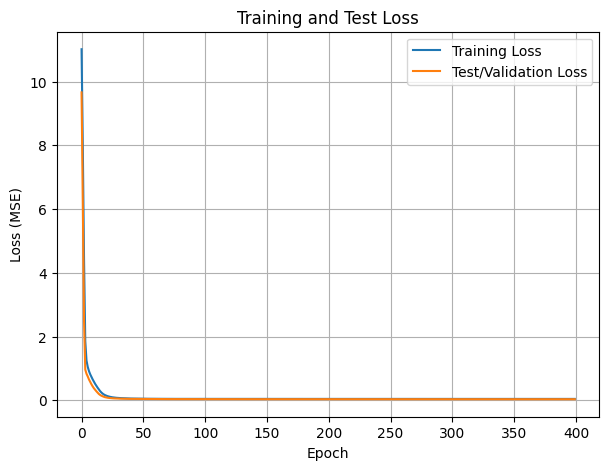

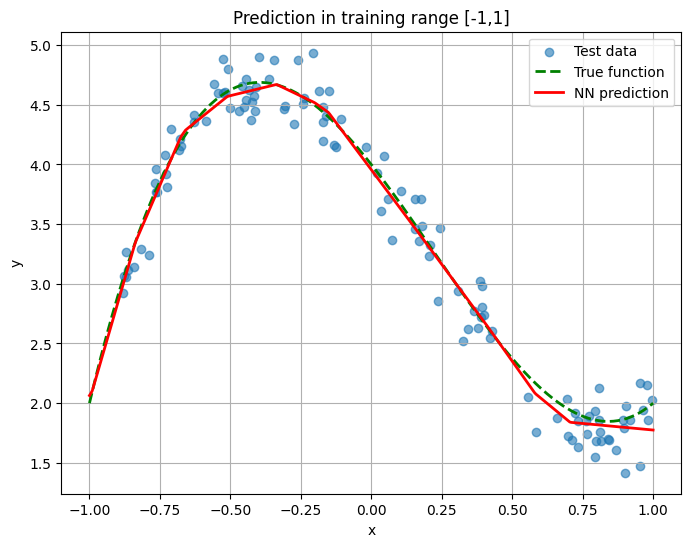

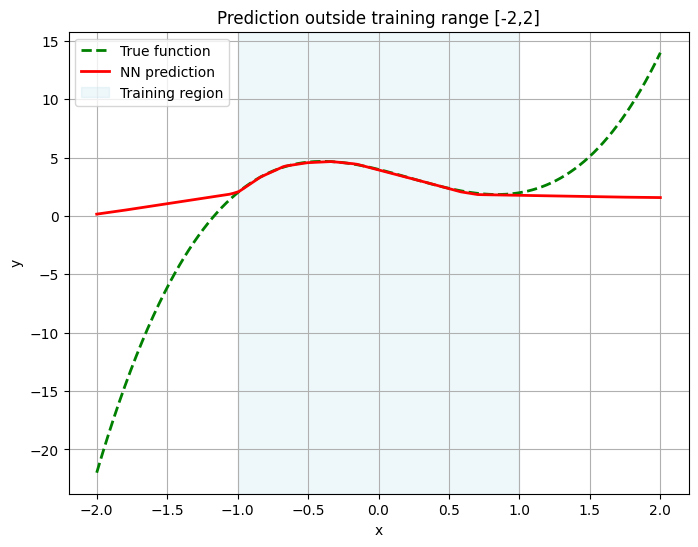

Best model performance on test set:
MSE  = 0.031926
MAE  = 0.142313
RMSE = 0.178680
R^2  = 0.974361


In [38]:
print("Best configuration:")
for k, v in best_params.items():
    print(f"{k}: {v}")

plot_loss_curves(best_result)
plot_in_range(best_result)
plot_out_of_range(best_result)

print("Best model performance on test set:")
print(f"MSE  = {best_result['mse']:.6f}")
print(f"MAE  = {best_result['mae']:.6f}")
print(f"RMSE = {best_result['rmse']:.6f}")
print(f"R^2  = {best_result['r2']:.6f}")

### Commento sulla miglior configurazione trovata

La grid search individua come configurazione migliore una rete con **due hidden layers da 32 neuroni ciascuno**, attivazione **ReLU**, ottimizzatore **Adam**, loss **MSE**, addestrata per **400 epoche** con **batch size 16**. Questo risultato è coerente con la natura del problema.

La funzione da approssimare,

$$
f(x)=4-3x-2x^2+3x^3,
$$

è una funzione **non lineare ma regolare**, quindi non può essere descritta correttamente da un modello puramente lineare. Per questo motivo è necessario introdurre almeno uno o più strati nascosti con una funzione di attivazione non lineare. Una rete con due layer nascosti ha capacità sufficiente per rappresentare bene la curvatura del polinomio senza essere eccessivamente complessa.

La scelta di **32 neuroni per layer** rappresenta un buon compromesso tra:
- **capacità espressiva**, necessaria per catturare l’andamento cubico;
- **contenimento della complessità**, per evitare un numero eccessivo di parametri che potrebbe favorire overfitting.

L’attivazione **ReLU** risulta efficace perché introduce non linearità in modo semplice e stabile dal punto di vista numerico, facilitando l’ottimizzazione. Anche se per funzioni lisce si potrebbero considerare altre attivazioni come `tanh`, ReLU spesso garantisce un training più efficiente.

L’ottimizzatore **Adam** è una scelta naturale in questo contesto: combina rapidità di convergenza e robustezza, adattando automaticamente il learning rate dei parametri. Questo lo rende generalmente più efficace di una discesa del gradiente standard su problemi di regressione non lineare.

La loss **MSE** è appropriata perché penalizza maggiormente errori grandi ed è la funzione standard per problemi di regressione continua. Inoltre è coerente con le metriche finali osservate (`mse`, `rmse`, `r2`), che mostrano una buona qualità del fit.

Le **400 epoche** indicano che il modello beneficia di un addestramento relativamente lungo per convergere bene. Il **batch size 16**, piuttosto piccolo, introduce aggiornamenti più frequenti dei pesi e può aiutare il modello a trovare una soluzione con buona generalizzazione.

Infine, il valore di

- \(\text{MSE} \approx 0.032\),
- \(\text{RMSE} \approx 0.178\),
- \(R^2 \approx 0.975\),

mostra che la rete riesce a riprodurre molto bene il comportamento della funzione nel range di training, pur in presenza di rumore nei dati. In sintesi, questa configurazione emerge come il miglior compromesso tra **semplicità del modello**, **qualità del fit** e **capacità di generalizzazione**.

### Previsione fuori range
Sebbene all'interno del range di allenamento il modello approssima molto bene la funzione polinomiale, in un range più ampio, fuori dalla zona di allenamento, non ci si può aspettare una buona estrapolazione.

___
### Exercise 11.3
  
Try to extend the model to fit a simple trigonometric 2D function such as $f(x,y) = \sin(x^2+y^2)$ in the range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$.
___

### Passaggi principali:

1. **Definizione della rete neurale:**

- La rete è composta da uno o più strati nascosti con un numero variabile di neuroni.
- Funzioni di attivazione: tanh o relu.
- Ottimizzatori: adam o rmsprop.
- Funzione di perdita: mse.

2. **Grid search:**

- Si esplorano diverse configurazioni della rete, come nell'esercizio 11.2.
- Si calcolano le metriche di performance per ogni configurazione.

3. **Visualizzazione dei risultati:**

- Si confrontano la funzione vera e le predizioni del modello su una griglia 2D.
- Si analizzano le curve di perdita (training e validation loss).

4. **Metriche considerate:**
- MSE, MAE, RMSE, R²: come negli esercizi precedenti.
- Predizioni 3D: confronto visivo tra la funzione vera e le predizioni del modello.

In [40]:
def true_function_2d(x, y):
    return np.sin(x**2 + y**2)

def generate_2d_data(n_points=2000, sigma=0.0, seed=0):
    np.random.seed(seed)
    x = np.random.uniform(-1.5, 1.5, n_points)
    y = np.random.uniform(-1.5, 1.5, n_points)
    z = true_function_2d(x, y) + np.random.normal(0, sigma, n_points)
    
    X = np.column_stack((x, y))
    return X, z


In [43]:
def run_2d_experiment(hidden_layers=(32,32), activation='tanh', optimizer='adam',
                      loss='mse', epochs=200, batch_size=32,
                      n_points=2000, sigma=0.0, seed=0, verbose=0):

    X, z = generate_2d_data(n_points=n_points, sigma=sigma, seed=seed)

    X_train, X_test, z_train, z_test = train_test_split(
        X, z, test_size=0.2, random_state=42, shuffle=True
    )

    tf.random.set_seed(seed)
    model = build_mlp(hidden_layers=hidden_layers,
                      activation=activation,
                      optimizer=optimizer,
                      loss=loss,
                      input_dim=2)

    history = model.fit(
        X_train, z_train,
        validation_data=(X_test, z_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=verbose,
        shuffle=True
    )

    z_pred = model.predict(X_test, verbose=0).flatten()

    mse = mean_squared_error(z_test, z_pred)
    mae = mean_absolute_error(z_test, z_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(z_test, z_pred)

    return {
        'model': model,
        'history': history,
        'X_train': X_train,
        'X_test': X_test,
        'z_train': z_train,
        'z_test': z_test,
        'z_pred': z_pred,
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'hidden_layers': hidden_layers,
        'activation': activation,
        'optimizer': optimizer,
        'loss': loss,
        'epochs': epochs,
        'batch_size': batch_size,
        'n_points': n_points,
        'sigma': sigma
    }
    
# grid search per il modello 2D
param_grid_2d = {
    'hidden_layers': [
        (16,),
        (32,),
        (64,),
        (32, 32),
        (64, 32),
        (64, 64)
    ],
    'activation': ['tanh', 'relu'],
    'optimizer': ['adam', 'rmsprop'],
    'loss': ['mse'],
    'epochs': [100, 200, 400],
    'batch_size': [16, 32]
}

In [44]:
grid_results_2d = []

for hidden_layers in param_grid_2d['hidden_layers']:
    for activation in param_grid_2d['activation']:
        for optimizer in param_grid_2d['optimizer']:
            for loss in param_grid_2d['loss']:
                for epochs in param_grid_2d['epochs']:
                    for batch_size in param_grid_2d['batch_size']:

                        result = run_2d_experiment(
                            hidden_layers=hidden_layers,
                            activation=activation,
                            optimizer=optimizer,
                            loss=loss,
                            epochs=epochs,
                            batch_size=batch_size,
                            n_points=2000,
                            sigma=0.0,
                            seed=0,
                            verbose=0
                        )

                        grid_results_2d.append({
                            'hidden_layers': str(hidden_layers),
                            'activation': activation,
                            'optimizer': optimizer,
                            'loss': loss,
                            'epochs': epochs,
                            'batch_size': batch_size,
                            'mse': result['mse'],
                            'mae': result['mae'],
                            'rmse': result['rmse'],
                            'r2': result['r2']
                        })

                        print(f"{hidden_layers}, {activation}, {optimizer}, epochs={epochs}, batch={batch_size} -> MSE={result['mse']:.5f}, R2={result['r2']:.5f}")

(16,), tanh, adam, epochs=100, batch=16 -> MSE=0.10732, R2=0.25917
(16,), tanh, adam, epochs=100, batch=32 -> MSE=0.13433, R2=0.07269
(16,), tanh, adam, epochs=200, batch=16 -> MSE=0.06349, R2=0.56169
(16,), tanh, adam, epochs=200, batch=32 -> MSE=0.08678, R2=0.40091
(16,), tanh, adam, epochs=400, batch=16 -> MSE=0.05998, R2=0.58592
(16,), tanh, adam, epochs=400, batch=32 -> MSE=0.06350, R2=0.56164
(16,), tanh, rmsprop, epochs=100, batch=16 -> MSE=0.12077, R2=0.16629
(16,), tanh, rmsprop, epochs=100, batch=32 -> MSE=0.13564, R2=0.06365
(16,), tanh, rmsprop, epochs=200, batch=16 -> MSE=0.07344, R2=0.49303
(16,), tanh, rmsprop, epochs=200, batch=32 -> MSE=0.07455, R2=0.48535
(16,), tanh, rmsprop, epochs=400, batch=16 -> MSE=0.04089, R2=0.71775
(16,), tanh, rmsprop, epochs=400, batch=32 -> MSE=0.07270, R2=0.49816
(16,), relu, adam, epochs=100, batch=16 -> MSE=0.03176, R2=0.78073
(16,), relu, adam, epochs=100, batch=32 -> MSE=0.05083, R2=0.64914
(16,), relu, adam, epochs=200, batch=16 -> M

In [45]:
grid_df_2d = pd.DataFrame(grid_results_2d)
grid_df_2d = grid_df_2d.sort_values(by='mse', ascending=True)

best_row_2d = grid_df_2d.iloc[0]

with open("best_nn_parameters_2d.txt", "w") as f:
    f.write("Best NN parameters for 2D trigonometric fit\n")
    f.write("-------------------------------------------\n")
    for col in grid_df_2d.columns:
        f.write(f"{col}: {best_row_2d[col]}\n")

In [46]:
# funzioni salvataggio dati e grafici

def load_best_parameters(filename):
    params = {}

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("Best NN parameters") or line.startswith("---"):
                continue

            key, value = line.split(": ", 1)

            if key == "hidden_layers":
                params[key] = ast.literal_eval(value)
            elif key in ["epochs", "batch_size"]:
                params[key] = int(value)
            elif key in ["mse", "mae", "rmse", "r2"]:
                params[key] = float(value)
            else:
                params[key] = value

    return params

def plot_loss_curves(result, title="Training and Test Loss"):
    history = result['history']

    plt.figure(figsize=(7,5))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Test/Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    
def plot_3d_prediction(result, grid_size=80):
    model = result['model']

    x_lin = np.linspace(-1.5, 1.5, grid_size)
    y_lin = np.linspace(-1.5, 1.5, grid_size)
    Xg, Yg = np.meshgrid(x_lin, y_lin)

    XY_grid = np.column_stack((Xg.ravel(), Yg.ravel()))
    Z_pred = model.predict(XY_grid, verbose=0).reshape(Xg.shape)
    Z_true = true_function_2d(Xg, Yg)

    fig = plt.figure(figsize=(14,6))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    ax1.plot_surface(Xg, Yg, Z_true, cmap='viridis', edgecolor='none')
    ax1.set_title("True function: sin(x² + y²)")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("z")

    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    ax2.plot_surface(Xg, Yg, Z_pred, cmap='plasma', edgecolor='none')
    ax2.set_title("NN prediction on training range")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("z")

    plt.tight_layout()
    plt.show()

In [48]:
# riallenamento modello migliore
best_params_2d = load_best_parameters("best_nn_parameters_2d.txt")

best_result_2d = run_2d_experiment(
    hidden_layers=best_params_2d['hidden_layers'],
    activation=best_params_2d['activation'],
    optimizer=best_params_2d['optimizer'],
    loss=best_params_2d['loss'],
    epochs=best_params_2d['epochs'],
    batch_size=best_params_2d['batch_size'],
    n_points=2000,
    sigma=0.0,
    seed=0,
    verbose=0
)

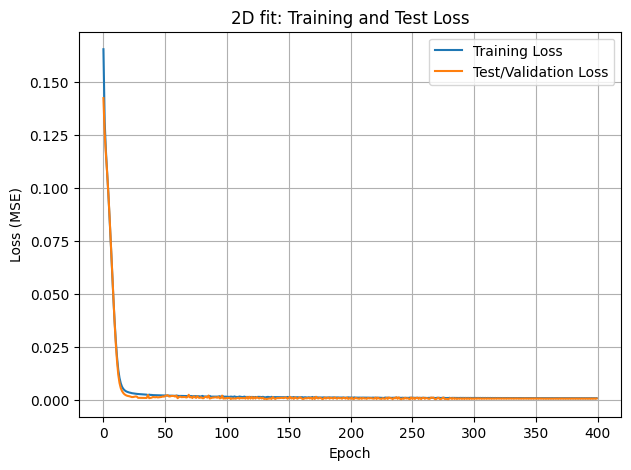

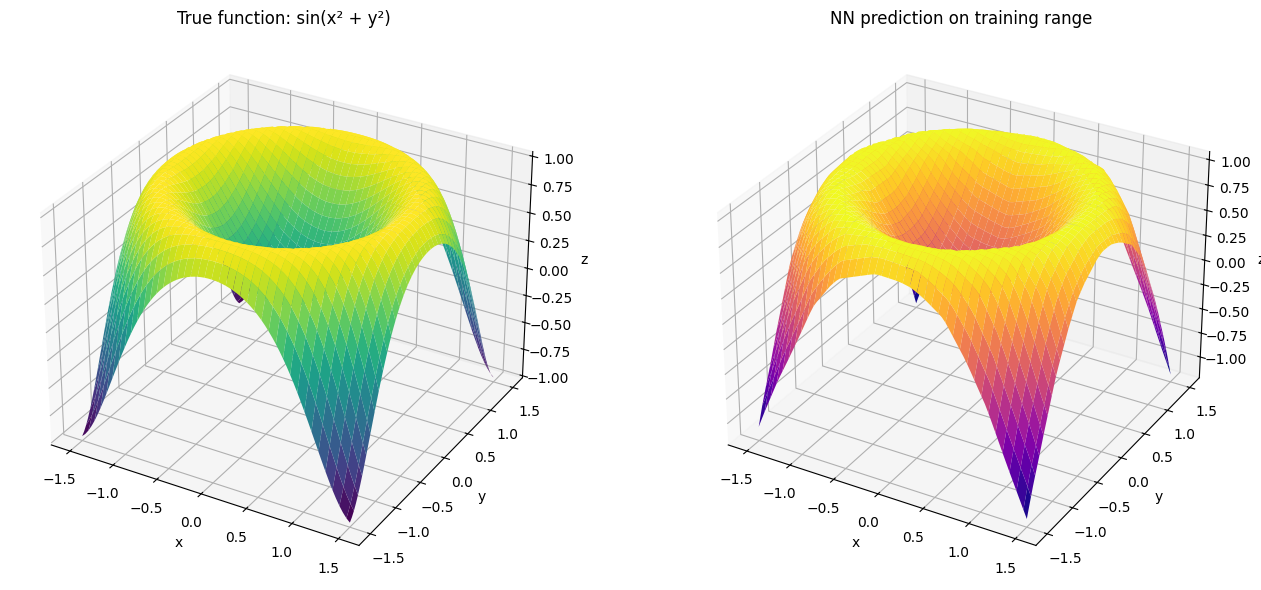

In [49]:
plot_loss_curves(best_result_2d, title="2D fit: Training and Test Loss")
plot_3d_prediction(best_result_2d, grid_size=80)

In [50]:
# guardo come si comporta il modello dell'esercizio 11.2
best_params_cubic = load_best_parameters("best_nn_parameters.txt")

cubic_like_result_2d = run_2d_experiment(
    hidden_layers=best_params_cubic['hidden_layers'],
    activation=best_params_cubic['activation'],
    optimizer=best_params_cubic['optimizer'],
    loss=best_params_cubic['loss'],
    epochs=best_params_cubic['epochs'],
    batch_size=best_params_cubic['batch_size'],
    n_points=2000,
    sigma=0.0,
    seed=0,
    verbose=0
)

In [51]:
# confronto modelli
comparison_df = pd.DataFrame([
    {
        'model': 'Best 2D model',
        'hidden_layers': str(best_params_2d['hidden_layers']),
        'activation': best_params_2d['activation'],
        'optimizer': best_params_2d['optimizer'],
        'epochs': best_params_2d['epochs'],
        'batch_size': best_params_2d['batch_size'],
        'mse': best_result_2d['mse'],
        'mae': best_result_2d['mae'],
        'rmse': best_result_2d['rmse'],
        'r2': best_result_2d['r2']
    },
    {
        'model': 'Cubic-fit architecture adapted to 2D',
        'hidden_layers': str(best_params_cubic['hidden_layers']) if 'best_params_cubic' in globals() else '(32, 32)',
        'activation': best_params_cubic['activation'] if 'best_params_cubic' in globals() else 'relu',
        'optimizer': best_params_cubic['optimizer'] if 'best_params_cubic' in globals() else 'adam',
        'epochs': best_params_cubic['epochs'] if 'best_params_cubic' in globals() else 400,
        'batch_size': best_params_cubic['batch_size'] if 'best_params_cubic' in globals() else 16,
        'mse': cubic_like_result_2d['mse'],
        'mae': cubic_like_result_2d['mae'],
        'rmse': cubic_like_result_2d['rmse'],
        'r2': cubic_like_result_2d['r2']
    }
])

comparison_df

,model,hidden_layers,activation,optimizer,epochs,batch_size,mse,mae,rmse,r2
0,Best 2D model,"(64, 64)",relu,rmsprop,400,32,0.000503,0.018277,0.022436,0.996525
1,Cubic-fit architecture adapted to 2D,"(32, 32)",relu,adam,400,16,0.000387,0.014755,0.019667,0.997330


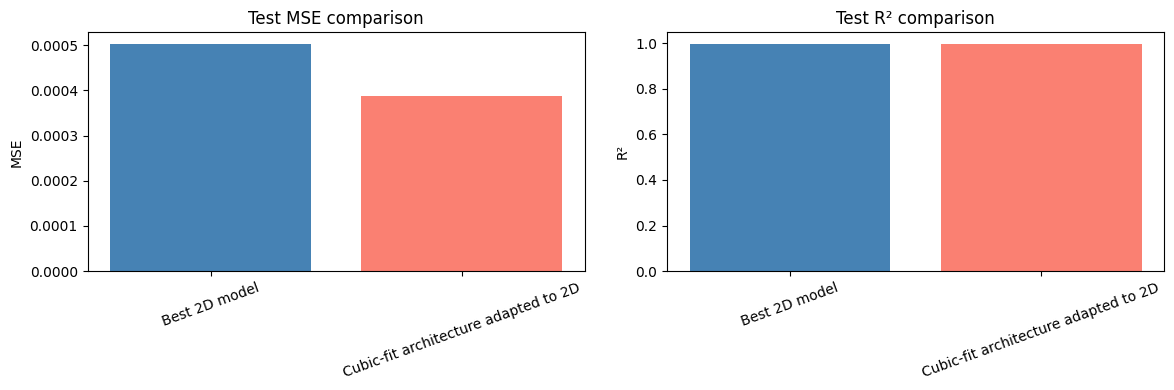

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].bar(comparison_df['model'], comparison_df['mse'], color=['steelblue', 'salmon'])
axes[0].set_title('Test MSE comparison')
axes[0].set_ylabel('MSE')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(comparison_df['model'], comparison_df['r2'], color=['steelblue', 'salmon'])
axes[1].set_title('Test R² comparison')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Commento finale sull’estensione al caso 2D

Per approssimare la funzione bidimensionale

$$
f(x,y)=\sin(x^2+y^2),
\qquad x,y \in \left[-\frac{3}{2},\frac{3}{2}\right],
$$

sono stati confrontati due approcci:

1. una rete neurale ottimizzata appositamente per il problema 2D tramite grid search;
2. la rete migliore trovata nel caso della regressione polinomiale 1D, adattata semplicemente a ricevere un input bidimensionale.

I risultati ottenuti mostrano che entrambi i modelli riescono ad apprendere bene la funzione, con errori molto piccoli e valori di ($R^2$) prossimi a 1. Questo indica che la funzione, pur essendo non lineare, è sufficientemente regolare da poter essere approssimata con grande accuratezza da architetture relativamente compatte.

In particolare, il modello selezionato tramite grid search per il caso 2D è:

- hidden layers: `(64, 64)`
- activation: `relu`
- optimizer: `rmsprop`

e ottiene:

- ($\text{MSE} = 5.03 \times 10^{-4}$)
- ($\text{MAE} = 1.83 \times 10^{-2}$)
- ($\text{RMSE} = 2.24 \times 10^{-2}$)
- ($R^2 = 0.9965$)

Sorprendentemente, l’architettura derivata dal problema polinomiale 1D, cioè:

- hidden layers: `(32, 32)`
- activation: `relu`
- optimizer: `adam`

produce metriche **leggermente migliori**:

- ($\text{MSE} = 3.87 \times 10^{-4}$)
- ($\text{MAE} = 1.48 \times 10^{-2}$)
- ($\text{RMSE} = 1.97 \times 10^{-2}$)
- ($R^2 = 0.9973$)

Questo risultato è plausibile. La grid search esplora infatti solo un insieme finito di configurazioni, quindi il “modello migliore” trovato è il migliore all’interno della griglia testata, ma non necessariamente il migliore in assoluto. Inoltre, una rete leggermente più piccola può generalizzare meglio di una più grande, specialmente quando la funzione target è liscia e il dataset è ben campionato.

Dal confronto emerge quindi un punto importante: una maggiore complessità architetturale non garantisce automaticamente prestazioni migliori. Il modello `(64,64)` ha una capacità rappresentativa superiore, ma in questo caso la funzione non richiede necessariamente tale complessità aggiuntiva. La rete `(32,32)` risulta già sufficientemente espressiva da catturare la struttura di ($\sin(x^2+y^2)$), e beneficia anche della buona stabilità dell’ottimizzatore Adam e del batch size più piccolo.

In conclusione:

- reti neurali feed-forward semplici possono approssimare con grande accuratezza anche funzioni non lineari di due variabili;
- l’adattamento di un’architettura efficace da un problema a un altro può funzionare bene;
- il modello “migliore” dipende non solo dalla complessità della funzione, ma anche dal compromesso tra **capacità del modello**, **ottimizzazione** e **generalizzazione**;
- una grid search è molto utile per orientare la scelta, ma i risultati vanno sempre interpretati in modo empirico e non assoluto.

Nel complesso, entrambe le reti mostrano ottime prestazioni, ma il fatto che il modello più compatto ottenga risultati persino leggermente migliori suggerisce che, per questa funzione 2D, una complessità moderata sia già sufficiente per ottenere un fit eccellente.